# Project SP5 - Finite State Markov Chain: Conditional Expectation Estimation

## S4965918 - Edoardo Vassallo

**Goal:** Given a trajectory $X_1, \ldots, X_T$ from a finite-state Markov chain, estimate  
$$\hat{f}(x) \approx \mathbb{E}[X_{t+1} \mid X_t = x]$$
using two methods:
1. **Monte-Carlo conditional expectation** - empirical average of next states per starting state
2. **Kernel VAR (p=1)** - kernelized regression on $(X_t, X_{t+1})$ pairs

**Splits:** Train on $[1, 0.8T]$, tune hyper-parameters on $[0.8T, 0.9T]$, test on $[0.9T, T]$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from itertools import product

np.random.seed(0)
plt.rcParams['figure.dpi'] = 110

---
## 1. Define the Markov Chain

We use a 4-state chain. Feel free to change `P` to experiment with more deterministic
vs. more uniform transition matrices — this corresponds to varying the "noise" of the chain.

The **true** conditional expectation is simply $\mathbb{E}[X_{t+1} \mid X_t = x] = \sum_j j \cdot P_{xj}$.

In [3]:
N_STATES = 4
states   = np.arange(N_STATES)

# ---- Transition matrix: rows = current state, columns = next state ----
# Try changing this to a more uniform matrix (higher entropy / "more noise")
# or to a nearly-deterministic one (low entropy / "less noise").
P = np.array([
    [0.70, 0.20, 0.05, 0.05],
    [0.10, 0.60, 0.20, 0.10],
    [0.05, 0.15, 0.60, 0.20],
    [0.10, 0.10, 0.30, 0.50],
])

assert np.allclose(P.sum(axis=1), 1.0), "Each row must sum to 1"

# True conditional expectation for each starting state
true_cond_exp = P @ states.astype(float)
print("True E[X_{t+1} | X_t = x]:")
for s in states:
    print(f"  x={s}  ->  {true_cond_exp[s]:.4f}")

# Stationary distribution (for reference)
eigvals, eigvecs = np.linalg.eig(P.T)
stationary = np.real(eigvecs[:, np.argmin(np.abs(eigvals - 1))])
stationary /= stationary.sum()
print(f"\nStationary distribution: {stationary.round(3)}")

True E[X_{t+1} | X_t = x]:
  x=0  ->  0.4500
  x=1  ->  1.3000
  x=2  ->  1.9500
  x=3  ->  2.2000

Stationary distribution: [0.211 0.274 0.314 0.201]


---
## 2. Generate Trajectory and Split

Play with different values of `T`. Larger `T` → more data → both methods should converge.

T=2000  |  Train: 1600  Val: 200  Test: 200


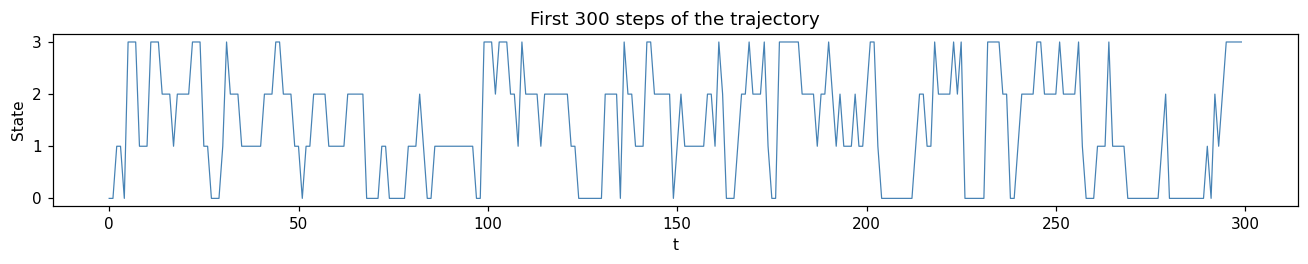

In [4]:
def generate_trajectory(P, T, seed=None):
    """Simulate one trajectory of length T from the Markov chain."""
    rng  = np.random.default_rng(seed)
    N    = P.shape[0]
    traj = np.empty(T, dtype=int)
    traj[0] = rng.integers(N)
    for t in range(1, T):
        traj[t] = rng.choice(N, p=P[traj[t - 1]])
    return traj


def split_trajectory(traj):
    """80 / 10 / 10 train / val / test split."""
    T         = len(traj)
    train_end = int(0.80 * T)
    val_end   = int(0.90 * T)
    return traj[:train_end], traj[train_end:val_end], traj[val_end:]


# --- Main experiment trajectory ---
T    = 2000          # <-- change this!
traj = generate_trajectory(P, T, seed=42)

X_train, X_val, X_test = split_trajectory(traj)
print(f"T={T}  |  Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

# Quick look at the trajectory
fig, ax = plt.subplots(figsize=(12, 2.5))
ax.plot(traj[:300], lw=0.8, color='steelblue')
ax.set_title('First 300 steps of the trajectory')
ax.set_xlabel('t');  ax.set_ylabel('State')
ax.set_yticks(states)
plt.tight_layout(); plt.show()

---
## 3. Method 1 — Monte Carlo Conditional Expectation

For each state $x$, we collect all indices $t$ where $X_t = x$ and average the next values:
$$\hat{f}_{MC}(x) = \frac{1}{|\{t : X_t = x\}|} \sum_{t : X_t = x} X_{t+1}$$

This is equivalent to estimating $\hat{P}_{xj}$ (empirical counts) and then computing
$\hat{f}_{MC}(x) = \sum_j j \cdot \hat{P}_{xj}$.

In [5]:
def fit_monte_carlo(X_train, N_states):
    """
    Estimate E[X_{t+1} | X_t = x] by empirical averaging.
    Returns array of shape (N_states,).
    """
    sums   = np.zeros(N_states)
    counts = np.zeros(N_states)
    for t in range(len(X_train) - 1):
        sums[X_train[t]]   += X_train[t + 1]
        counts[X_train[t]] += 1
    mask = counts > 0
    result = np.full(N_states, np.nan)
    result[mask] = sums[mask] / counts[mask]
    return result, counts


mc_est, mc_counts = fit_monte_carlo(X_train, N_STATES)

print("Visits per state in training set:", mc_counts.astype(int))
print("\n{:<6} {:>12} {:>15} {:>12}".format("State", "True", "MC estimate", "Error"))
print("-" * 48)
for s in states:
    print(f"{s:<6} {true_cond_exp[s]:>12.4f} {mc_est[s]:>15.4f} {abs(mc_est[s]-true_cond_exp[s]):>12.4f}")

Visits per state in training set: [318 449 513 319]

State          True     MC estimate        Error
------------------------------------------------
0            0.4500          0.4308       0.0192
1            1.3000          1.3051       0.0051
2            1.9500          1.9630       0.0130
3            2.2000          2.2069       0.0069


---
## 4. Method 2 — Kernel VAR (p=1)

We treat the problem as a supervised regression problem:
$$\text{inputs: } x_t = X_t \qquad \text{outputs: } y_t = X_{t+1}$$

The model is $f(x) = \sum_{i=1}^n c_i\, k(x, x_i)$, where the coefficients $c$ are found by
solving the **regularized kernel system** (kernel ridge regression):
$$(K + \lambda n I)\, c = y,$$
where $K_{ij} = k(x_i, x_j)$ and $\lambda > 0$ is the regularization parameter.

We use a **Gaussian kernel** $k(x, x') = \exp\!\left(-\frac{(x - x')^2}{2\sigma^2}\right)$.

> **Note:** The bandwidth $\sigma$ controls how much distant states influence one another.
> For discrete states, $\sigma$ acts as the smoothing width between integer points.

In [6]:
# ---- Kernel utilities ----

def gaussian_kernel(X, Y, sigma):
    """Gaussian kernel matrix between arrays X (n,) and Y (m,)."""
    X = np.array(X, dtype=float).reshape(-1, 1)
    Y = np.array(Y, dtype=float).reshape(-1, 1)
    sq_dists = cdist(X, Y, 'sqeuclidean')       # (n, m)
    return np.exp(-sq_dists / (2.0 * sigma**2))


class KernelVAR:
    """Kernel VAR(1): f(x) = sum_i c_i k(x, x_i) learned via kernel ridge regression."""

    def __init__(self, sigma=1.0, lam=1e-3):
        self.sigma = sigma
        self.lam   = lam

    def fit(self, X_train):
        self.X_in = X_train[:-1].astype(float)   # x_t
        y         = X_train[1:].astype(float)     # x_{t+1}
        n = len(self.X_in)
        K = gaussian_kernel(self.X_in, self.X_in, self.sigma)
        self.c = np.linalg.solve(K + self.lam * n * np.eye(n), y)
        return self

    def predict(self, X_new):
        X_new = np.asarray(X_new, dtype=float)
        k_vec = gaussian_kernel(X_new, self.X_in, self.sigma)   # (m, n)
        return k_vec @ self.c


def mean_pred_error(X, predict_fn):
    """MSE on consecutive pairs in X."""
    X_in  = X[:-1]
    y_true = X[1:].astype(float)
    y_pred = predict_fn(X_in)
    return np.mean((y_true - y_pred) ** 2)

Best hyper-parameters:  sigma=3.0,  lambda=0.01
Best validation MSE:    0.6799


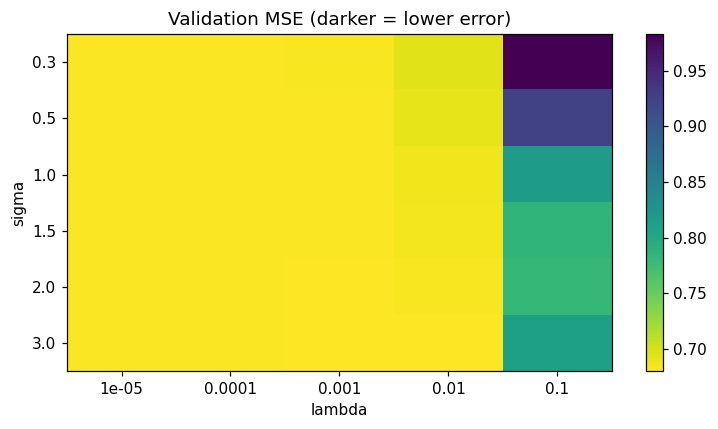

In [7]:
# ---- Hyper-parameter search on validation set ----

sigmas  = [0.3, 0.5, 1.0, 1.5, 2.0, 3.0]
lambdas = [1e-5, 1e-4, 1e-3, 1e-2, 0.1]

best_val_err = np.inf
best_sigma, best_lam = None, None
val_results = {}

for sigma, lam in product(sigmas, lambdas):
    model = KernelVAR(sigma=sigma, lam=lam).fit(X_train)
    err   = mean_pred_error(X_val, model.predict)
    val_results[(sigma, lam)] = err
    if err < best_val_err:
        best_val_err        = err
        best_sigma, best_lam = sigma, lam

print(f"Best hyper-parameters:  sigma={best_sigma},  lambda={best_lam}")
print(f"Best validation MSE:    {best_val_err:.4f}")

# Validation error heatmap
grid = np.array([[val_results[(s, l)] for l in lambdas] for s in sigmas])
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(grid, aspect='auto', cmap='viridis_r')
ax.set_xticks(range(len(lambdas))); ax.set_xticklabels([str(l) for l in lambdas])
ax.set_yticks(range(len(sigmas)));  ax.set_yticklabels([str(s) for s in sigmas])
ax.set_xlabel('lambda');  ax.set_ylabel('sigma')
ax.set_title('Validation MSE (darker = lower error)')
plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

In [8]:
# ---- Fit best Kernel VAR model ----

best_kvar  = KernelVAR(sigma=best_sigma, lam=best_lam).fit(X_train)
kvar_est   = best_kvar.predict(states.astype(float))

print("{:<6} {:>12} {:>15} {:>15}".format("State", "True", "MC estimate", "KernelVAR est"))
print("-" * 52)
for s in states:
    print(f"{s:<6} {true_cond_exp[s]:>12.4f} {mc_est[s]:>15.4f} {kvar_est[s]:>15.4f}")

State          True     MC estimate   KernelVAR est
----------------------------------------------------
0            0.4500          0.4308          0.5685
1            1.3000          1.3051          1.2793
2            1.9500          1.9630          1.8744
3            2.2000          2.2069          2.1783


---
## 5. Test Set Evaluation and Comparison

Test MSE  |  Monte Carlo: 0.5672  |  Kernel VAR: 0.5783


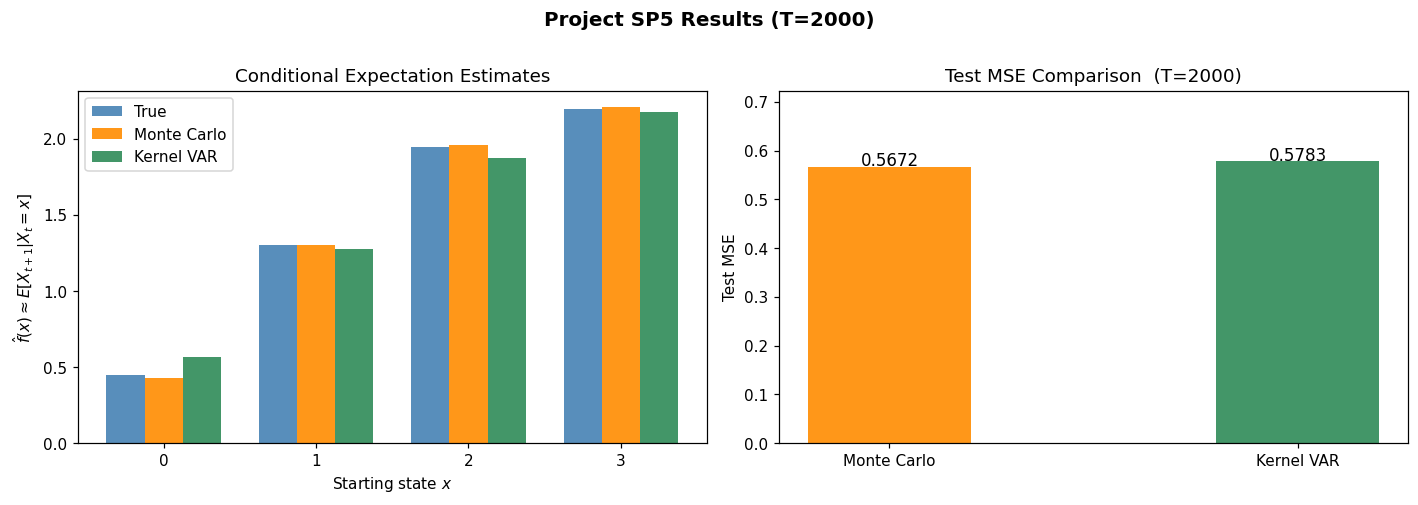

In [9]:
# ---- Predictors ----
mc_predict   = lambda X: np.array([mc_est[x] for x in X])
kvar_predict = best_kvar.predict

mc_test_err   = mean_pred_error(X_test, mc_predict)
kvar_test_err = mean_pred_error(X_test, kvar_predict)

print(f"Test MSE  |  Monte Carlo: {mc_test_err:.4f}  |  Kernel VAR: {kvar_test_err:.4f}")

# ---- Bar comparison ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: conditional expectation comparison per state
w = 0.25
x = np.arange(N_STATES)
axes[0].bar(x - w, true_cond_exp, w, label='True',       color='steelblue',  alpha=0.9)
axes[0].bar(x,     mc_est,        w, label='Monte Carlo', color='darkorange', alpha=0.9)
axes[0].bar(x + w, kvar_est,      w, label='Kernel VAR',  color='seagreen',   alpha=0.9)
axes[0].set_xlabel('Starting state $x$')
axes[0].set_ylabel(r'$\hat{f}(x) \approx E[X_{t+1}|X_t=x]$')
axes[0].set_title('Conditional Expectation Estimates')
axes[0].set_xticks(x)
axes[0].legend()

# Right: test MSE comparison
names  = ['Monte Carlo', 'Kernel VAR']
errors = [mc_test_err, kvar_test_err]
colors = ['darkorange', 'seagreen']
axes[1].bar(names, errors, color=colors, width=0.4, alpha=0.9)
for i, v in enumerate(errors):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=11)
axes[1].set_ylabel('Test MSE')
axes[1].set_title(f'Test MSE Comparison  (T={T})')
axes[1].set_ylim(0, max(errors) * 1.25)

plt.suptitle(f'Project SP5 Results (T={T})', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## 6. Experiment: Effect of Trajectory Length T

Run both methods over a range of T values. We expect both errors to decrease,
but with different rates and floor levels.

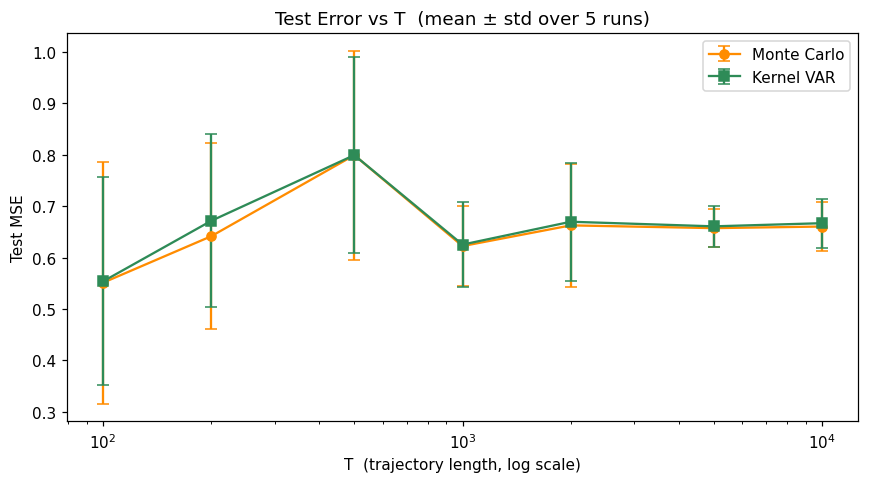

In [10]:
T_values   = [100, 200, 500, 1000, 2000, 5000, 10000]
N_REPEATS  = 5     # repeat each T to average out randomness

mc_errs   = {T_: [] for T_ in T_values}
kvar_errs = {T_: [] for T_ in T_values}

for T_ in T_values:
    for rep in range(N_REPEATS):
        traj_ = generate_trajectory(P, T_, seed=rep * 1000 + T_)
        tr, vl, te = split_trajectory(traj_)

        if len(te) < 2 or len(tr) < N_STATES * 5:
            continue

        # Monte Carlo
        mc_e, _ = fit_monte_carlo(tr, N_STATES)
        mc_p    = lambda X, e=mc_e: np.array([e[x] for x in X])
        mc_errs[T_].append(mean_pred_error(te, mc_p))

        # Kernel VAR — use best hyper-params found earlier (or re-tune if desired)
        kv = KernelVAR(sigma=best_sigma, lam=best_lam).fit(tr)
        kvar_errs[T_].append(mean_pred_error(te, kv.predict))

mc_mean   = [np.mean(mc_errs[T_])   for T_ in T_values]
kvar_mean = [np.mean(kvar_errs[T_]) for T_ in T_values]
mc_std    = [np.std(mc_errs[T_])    for T_ in T_values]
kvar_std  = [np.std(kvar_errs[T_])  for T_ in T_values]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(T_values, mc_mean,   yerr=mc_std,   fmt='o-', label='Monte Carlo', color='darkorange', capsize=4)
ax.errorbar(T_values, kvar_mean, yerr=kvar_std, fmt='s-', label='Kernel VAR',  color='seagreen',   capsize=4)
ax.set_xscale('log')
ax.set_xlabel('T  (trajectory length, log scale)')
ax.set_ylabel('Test MSE')
ax.set_title(f'Test Error vs T  (mean ± std over {N_REPEATS} runs)')
ax.legend()
plt.tight_layout(); plt.show()

---
## 7. Experiment: Effect of Transition Matrix "Noise"

We interpolate between a **deterministic** matrix (low stochasticity) and a **uniform** one
(maximum stochasticity) by mixing:
$$P(\alpha) = (1-\alpha) P_{\text{det}} + \alpha P_{\text{uniform}}$$

$\alpha=0$ → near-deterministic (easy to learn), $\alpha=1$ → uniform (hardest to predict).

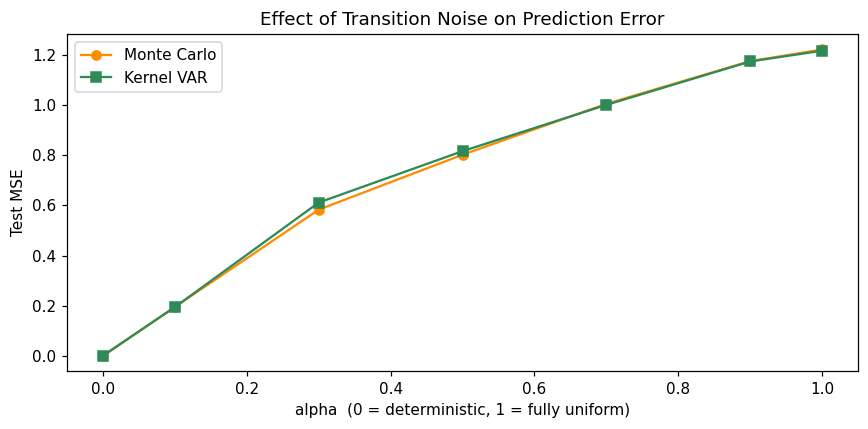

In [11]:
P_uniform = np.ones((N_STATES, N_STATES)) / N_STATES
P_det     = np.eye(N_STATES)   # completely deterministic (stay in same state)

alphas = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
T_noise = 2000

mc_noise   = []
kvar_noise = []

for alpha in alphas:
    P_alpha = (1 - alpha) * P_det + alpha * P_uniform
    traj_   = generate_trajectory(P_alpha, T_noise, seed=7)
    tr, vl, te = split_trajectory(traj_)

    mc_e, _ = fit_monte_carlo(tr, N_STATES)
    mc_p    = lambda X, e=mc_e: np.array([e[x] for x in X])
    mc_noise.append(mean_pred_error(te, mc_p))

    kv = KernelVAR(sigma=best_sigma, lam=best_lam).fit(tr)
    kvar_noise.append(mean_pred_error(te, kv.predict))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alphas, mc_noise,   'o-', label='Monte Carlo', color='darkorange')
ax.plot(alphas, kvar_noise, 's-', label='Kernel VAR',  color='seagreen')
ax.set_xlabel('alpha  (0 = deterministic, 1 = fully uniform)')
ax.set_ylabel('Test MSE')
ax.set_title('Effect of Transition Noise on Prediction Error')
ax.legend()
plt.tight_layout(); plt.show()

---
## 8. Summary & Discussion

Fill in your observations below after running the experiments.

| Setting | Monte Carlo MSE | Kernel VAR MSE | Winner |
|---------|:--------------:|:-------------:|:------:|
| T=…    |                |               |        |
| T=…    |                |               |        |

**Questions to think about:**

1. Why does Monte Carlo converge faster on a finite-state chain?
2. Kernel VAR introduces smoothing across states (via $\sigma$). When could this *help*?
   (Hint: think about what happens if one state is rarely visited.)
3. What is the minimum achievable test MSE? Can you express it analytically in terms of $P$?
   (Hint: it's the variance of $X_{t+1}$ under the stationary distribution.)
4. What happens to the error floor as $T \to \infty$? Should it go to zero?
5. Try adding a higher-order kernel (e.g. polynomial) — does it improve things?